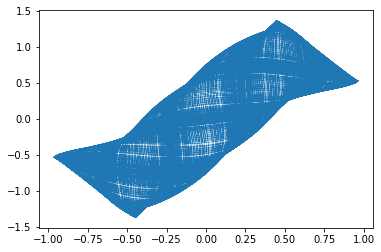

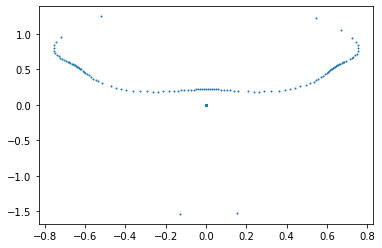

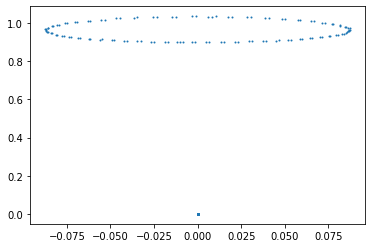

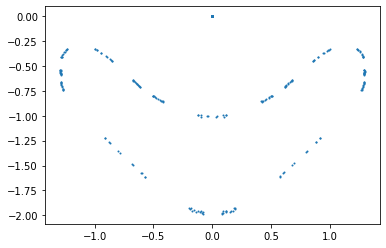

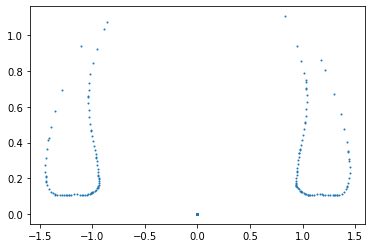

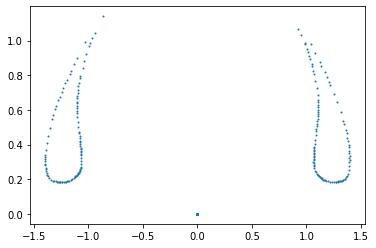

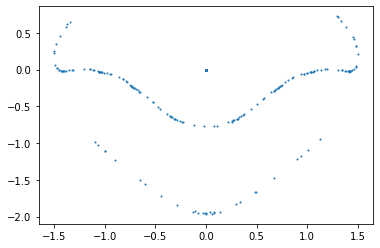

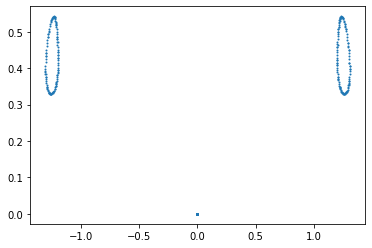

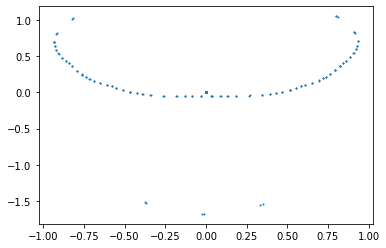

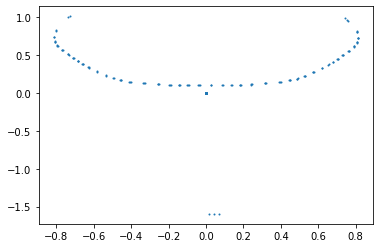

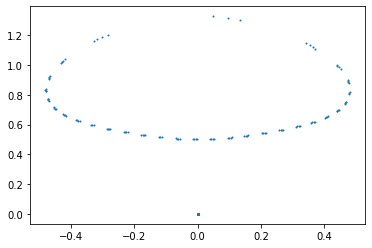

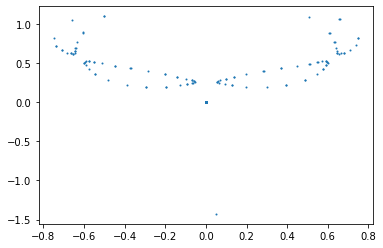

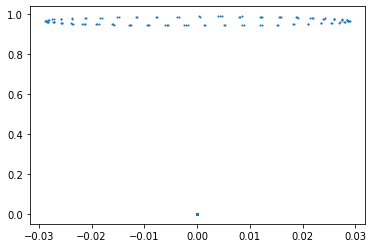

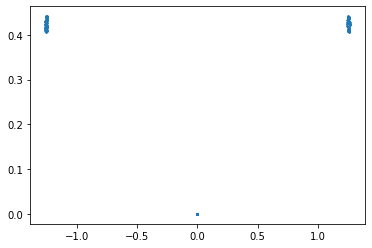

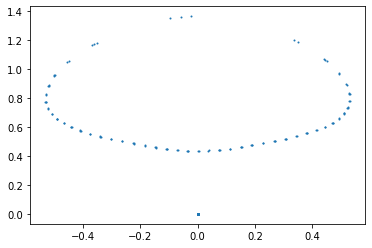

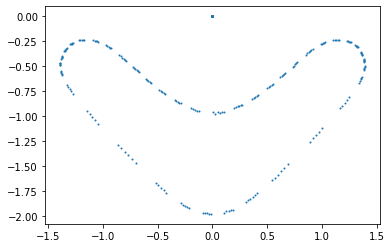

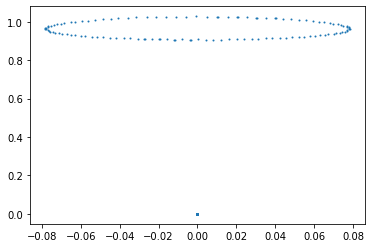

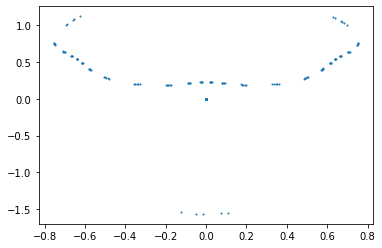

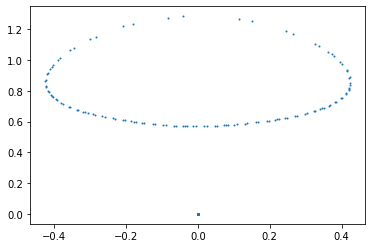

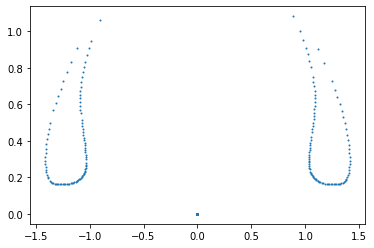

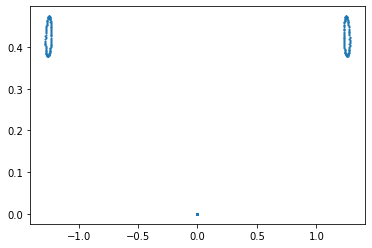

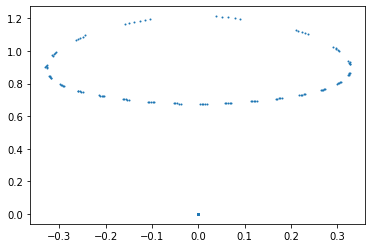

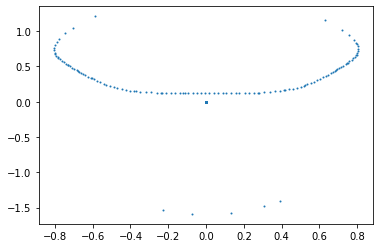

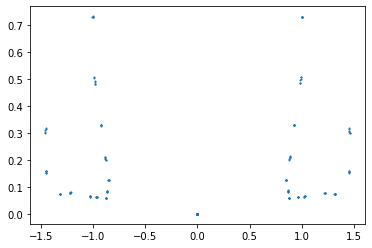

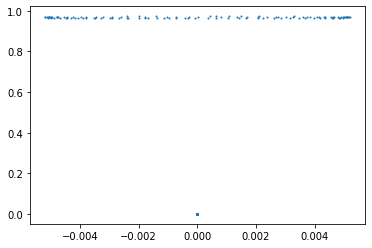

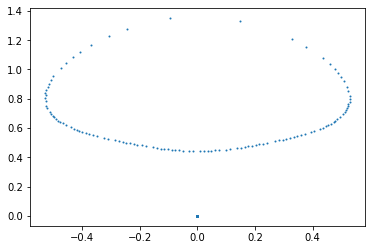

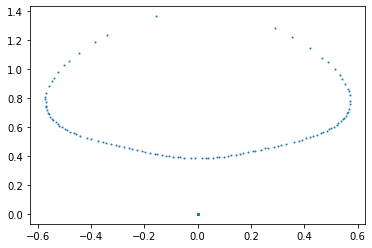

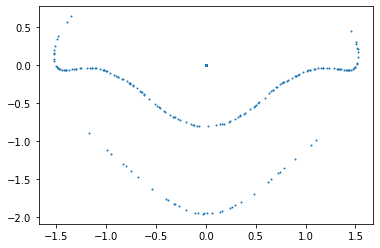

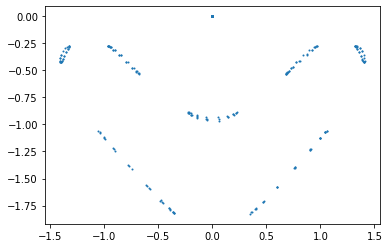

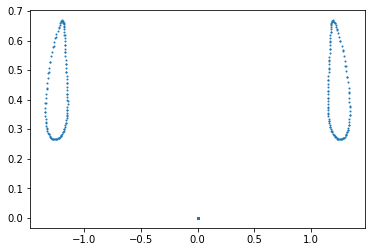

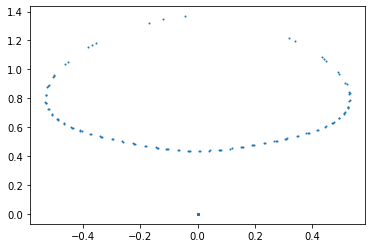

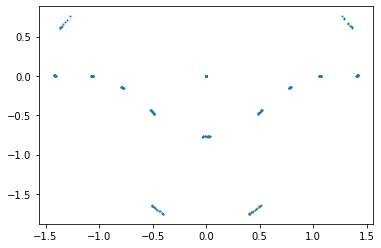

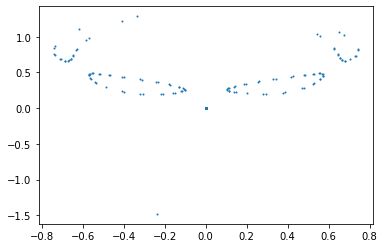

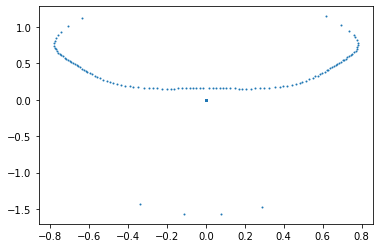

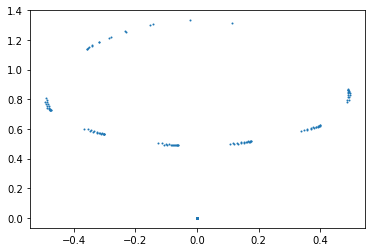

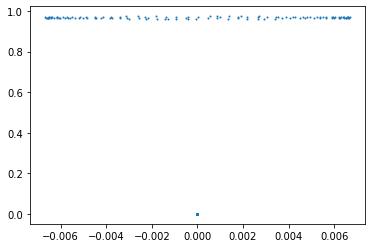

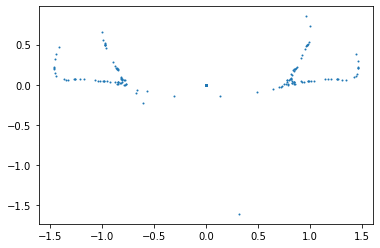

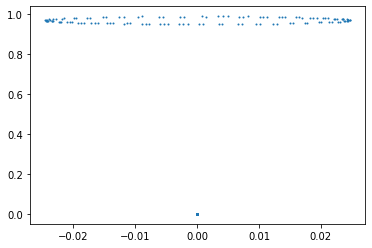

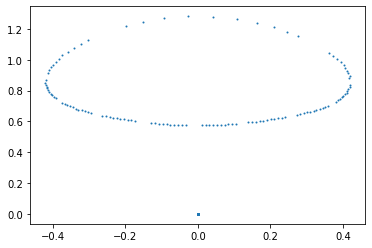

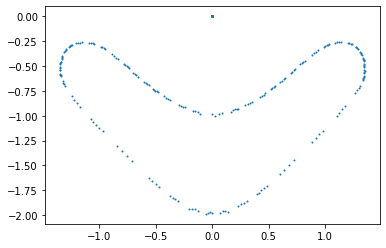

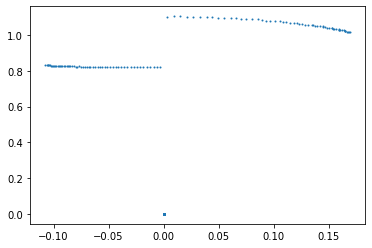

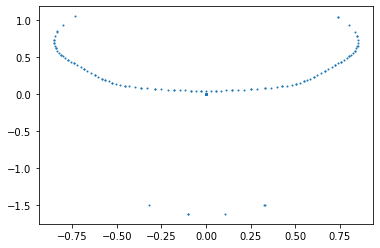

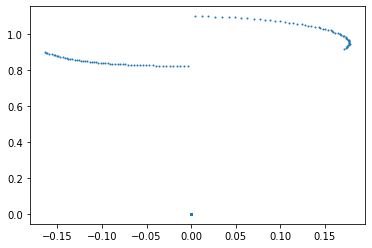

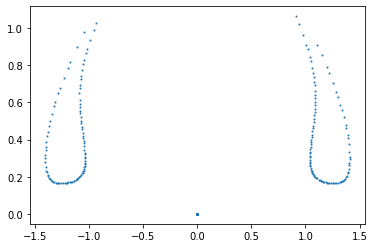

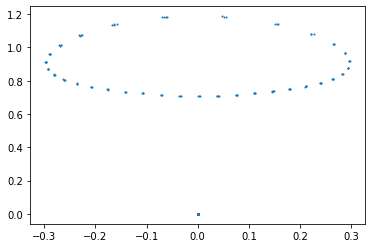

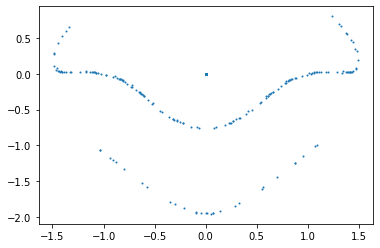

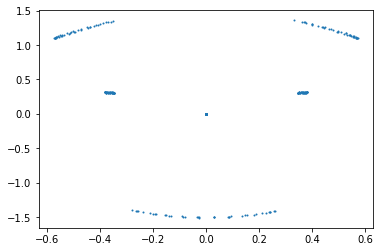

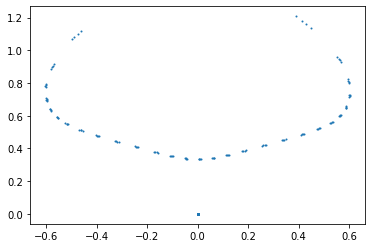

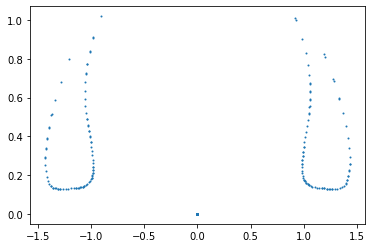

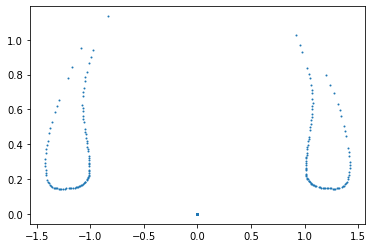

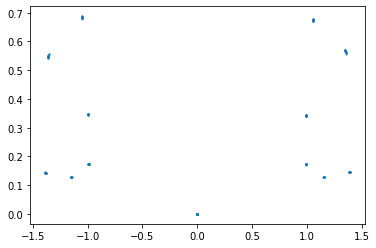

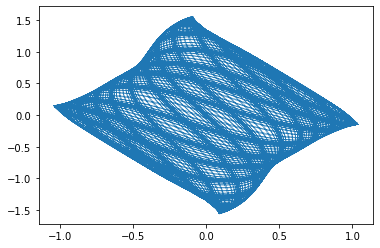

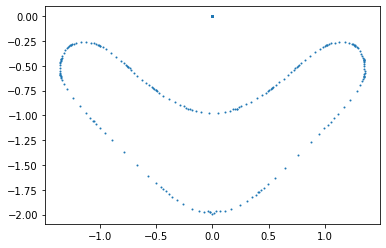

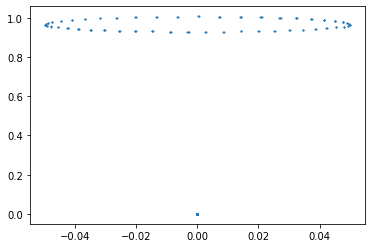

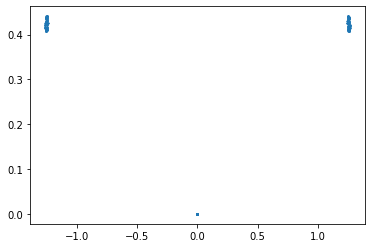

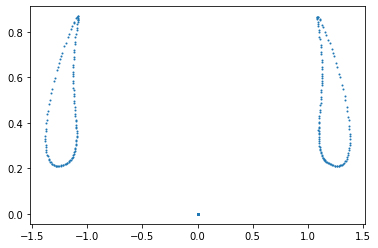

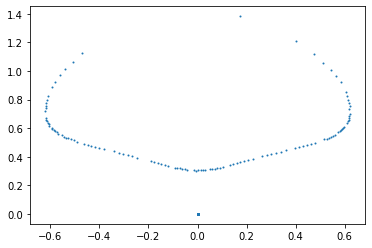

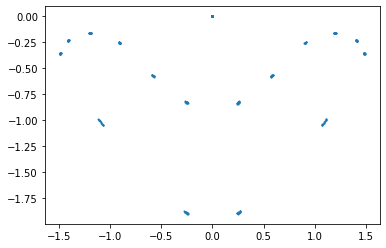

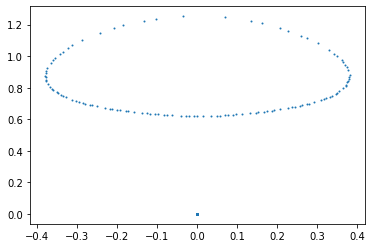

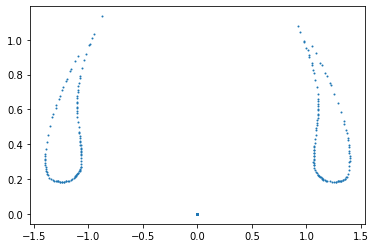

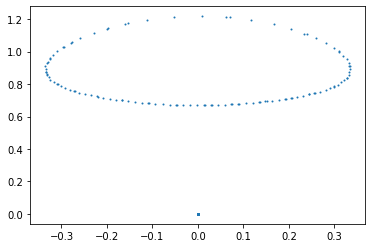

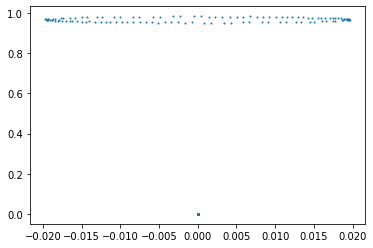

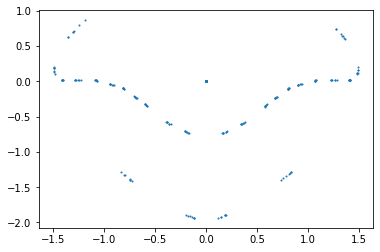

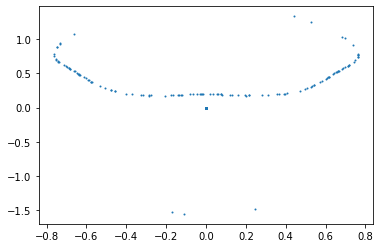

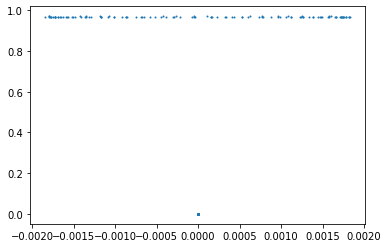

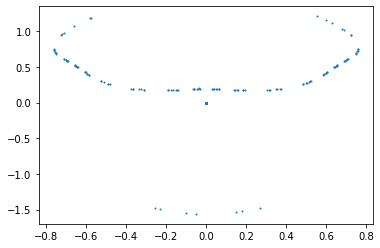

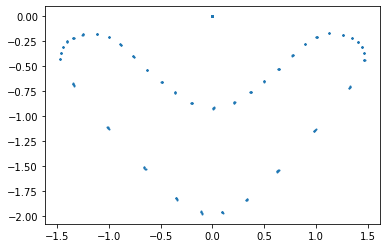

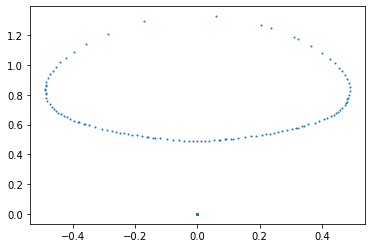

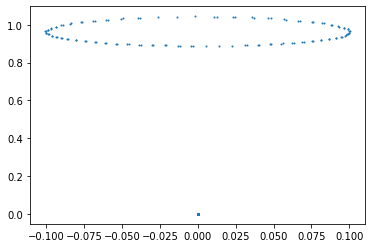

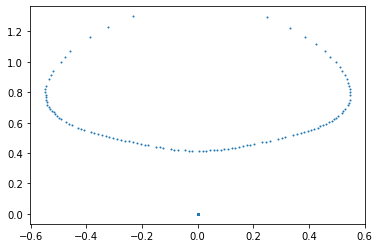

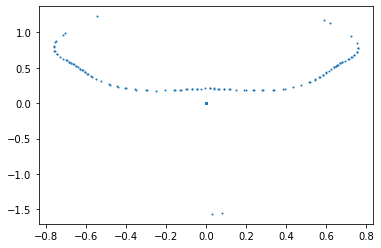

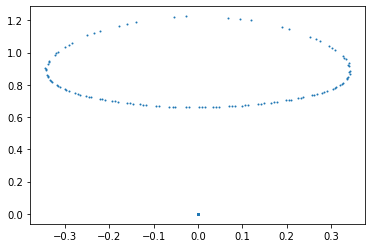

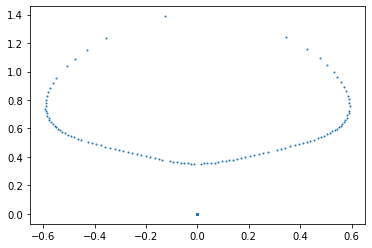

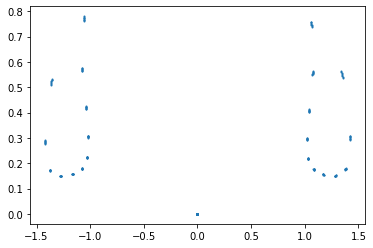

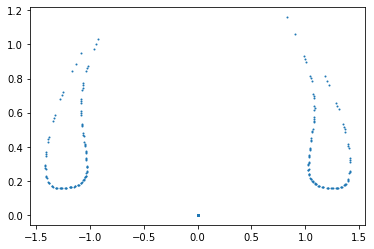

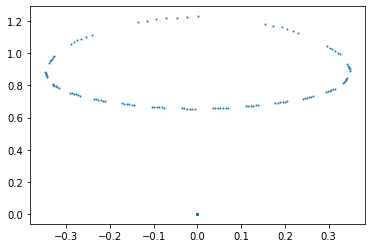

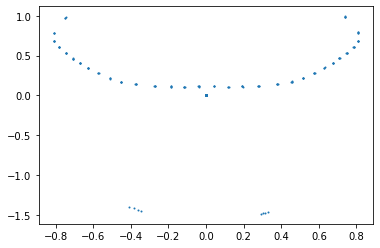

<Figure size 432x288 with 0 Axes>

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
DoublePendulum.py
Created on Oct 16 06:03:32 2020
"Introduction to Modern Dynamics" 2nd Edition (Oxford, 2019)
@author: nolte
"""
 
import numpy as np
from scipy import integrate
from matplotlib import pyplot as plt
import time
 
plt.close('all')
 
E = 1.       # Try 0.8 to 1.5
 
def flow_deriv(x_y_z_w,tspan):
    x, y, z, w = x_y_z_w
 
    A = w**2*np.sin(y-x);
    B = -2*np.sin(x);
    C = z**2*np.sin(y-x)*np.cos(y-x);
    D = np.sin(y)*np.cos(y-x);
    EE = 2 - (np.cos(y-x))**2;
     
    FF = w**2*np.sin(y-x)*np.cos(y-x);
    G = -2*np.sin(x)*np.cos(y-x);
    H = 2*z**2*np.sin(y-x);
    I = 2*np.sin(y);
    JJ = (np.cos(y-x))**2 - 2;
 
    a = z
    b = w
    c = (A+B+C+D)/EE
    d = (FF+G+H+I)/JJ
    return[a,b,c,d]
 
repnum = 75
 
np.random.seed(1)
for reploop  in range(repnum):
     
     
    px1 = 2*(np.random.random((1))-0.499)*np.sqrt(E);
    py1 = -px1 + np.sqrt(2*E - px1**2);            
 
    xp1 = 0   # Try 0.1
    yp1 = 0   # Try -0.2
     
    x_y_z_w0 = [xp1, yp1, px1, py1]
     
    tspan = np.linspace(1,1000,10000)
    x_t = integrate.odeint(flow_deriv, x_y_z_w0, tspan)
    siztmp = np.shape(x_t)
    siz = siztmp[0]
 
    if reploop % 50 == 0:
        plt.figure(2)
        lines = plt.plot(x_t[:,0],x_t[:,1])
        plt.setp(lines, linewidth=0.5)
        plt.show()
        time.sleep(0.1)
        #os.system("pause")
 
    y1 = np.mod(x_t[:,0]+np.pi,2*np.pi) - np.pi
    y2 = np.mod(x_t[:,1]+np.pi,2*np.pi) - np.pi
    y3 = np.mod(x_t[:,2]+np.pi,2*np.pi) - np.pi
    y4 = np.mod(x_t[:,3]+np.pi,2*np.pi) - np.pi
     
    py = np.zeros(shape=(10*repnum,))
    yvar = np.zeros(shape=(10*repnum,))
    cnt = -1
    last = y1[1]
    for loop in range(2,siz):
        if (last < 0)and(y1[loop] > 0):
            cnt = cnt+1
            del1 = -y1[loop-1]/(y1[loop] - y1[loop-1])
            py[cnt] = y4[loop-1] + del1*(y4[loop]-y4[loop-1])
            yvar[cnt] = y2[loop-1] + del1*(y2[loop]-y2[loop-1])
            last = y1[loop]
        else:
            last = y1[loop]
      
    plt.figure(3)
    lines = plt.plot(yvar,py,'o',ms=1)
    plt.show()
     
plt.savefig('DPen')